# Imports

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap
import seaborn #I like the visuals better than matplotlib. Is that ok? if not import matplotlib
import sys
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt


In [14]:
sys.path.insert(0,"../..")
from src.data import load
# Download latest version
file_path = "uciml/default-of-credit-card-clients-dataset"
df = load.get_kaggle_data(file_path)


In [15]:
print(df.head(), df.dtypes, df.isnull().sum())

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

In [16]:
df = df.rename(columns={'default.payment.next.month': 'target'})
X = df.drop('target', axis = 1)
y = df['target']

print(y.value_counts())
y_negs = y[y==0].count()
y_pos = y[y==1].count()

weight_adjust = y_negs/y_pos
print(weight_adjust)


target
0    23364
1     6636
Name: count, dtype: int64
3.5207956600361663


In [17]:
from src.models import train, evaluate, explain

In [18]:
X_train, X_test, y_train, y_test = train.split_data(df, 'target', 0.2)

## Gradient Boost

### Get Base Model

In [21]:
model = train.data_model(X_train, y_train, xgb(scale_pos_weight=weight_adjust, base_score = 0.5))
base_vals = evaluate.evaluate_model(model, X_test, y_test)
print(evaluate.evaluate_model(model, X_test, y_test))


              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4687
           1       0.45      0.57      0.50      1313

    accuracy                           0.75      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.75      0.76      6000



### SHAP Values

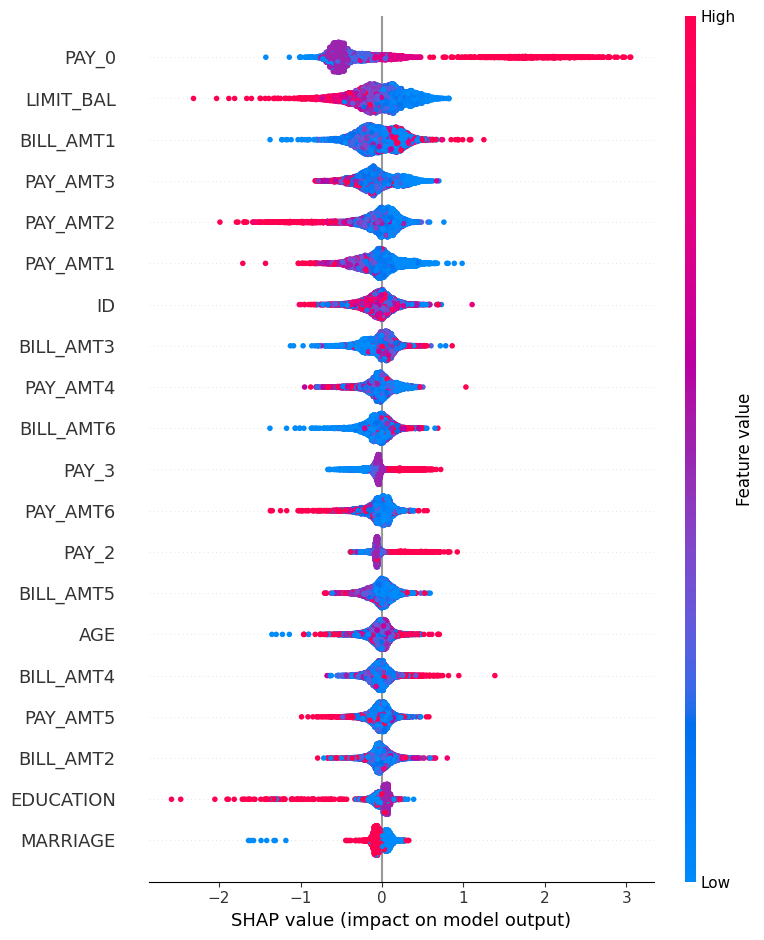

array([[ 0.10709202,  0.43682975,  0.03146073, ..., -0.01907509,
        -0.04026679, -0.02193989],
       [-0.16934316, -0.08412097, -0.06141715, ..., -0.11809141,
         0.1045557 , -0.12899202],
       [-0.00242756,  0.46159843, -0.05059702, ..., -0.07512557,
        -0.04763879, -0.0013064 ],
       ...,
       [-0.2367673 ,  0.33589363, -0.0555022 , ...,  0.00496847,
        -0.19736831, -0.14698069],
       [-0.09421616,  0.09920238, -0.02785843, ..., -0.13274845,
        -0.00138931,  0.09946183],
       [-0.31118688, -0.784342  , -0.00680573, ..., -0.2477763 ,
        -0.5200334 ,  0.06547178]], shape=(6000, 24), dtype=float32)

In [22]:
explain.shap_exp_xgb(X_test, model)

### Tune Hyperparameters

In [ ]:
model_tuned = train.data_model(X_train, y_train, 
                               xgb(scale_pos_weight=weight_adjust, 
                                   base_score = 0.5,
                                   max_depth = hyperparam_tuning.best_params_['max_depth'],
                                   n_estimators = hyperparam_tuning.best_params_['n_estimators'],
                                   learning_rate = hyperparam_tuning.best_params_['learning_rate']))
tuned_vals = evaluate.evaluate_model(model_tuned, X_test, y_test)
print(base_vals, tuned_vals)

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4687
           1       0.45      0.57      0.50      1313

    accuracy                           0.75      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.75      0.76      6000
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      4687
           1       0.46      0.63      0.53      1313

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.77      6000



In [19]:

hyperparam_tuning = RandomizedSearchCV(estimator = xgb(scale_pos_weight=weight_adjust, base_score = 0.5),
                                       n_iter=10,
                                       param_distributions= {'max_depth': [4,5,6],
                                                             'n_estimators': range(100,500),
                                                             'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]},
                                     scoring='recall').fit(X_train, y_train)

In [20]:
print(hyperparam_tuning.best_params_)

{'n_estimators': 105, 'max_depth': 4, 'learning_rate': 0.1}


### Evaluate AUC-PR

In [24]:
evaluate.auc_eval(model_tuned, X_test, y_test)

((array([0.21883333, 0.21886981, 0.2189063 , ..., 1.        , 1.        ,
         1.        ], shape=(5966,)),
  array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.52322925e-03, 7.61614623e-04, 0.00000000e+00], shape=(5966,)),
  array([0.04325524, 0.04697605, 0.05154197, ..., 0.9589109 , 0.95962113,
         0.961797  ], shape=(5965,), dtype=float32)),
 0.5514816605292547)

## LightGBM

### Base Model

In [67]:
lgb_model = train.data_model(X_train, y_train, lgb.LGBMClassifier(scale_pos_weight = weight_adjust, num_leaves=100, 
                                                                    max_depth= -1, learning_rate=0.1, n_estimators=250))
lgb_base_vals = evaluate.evaluate_model(lgb_model, X_test, y_test)
print(evaluate.evaluate_model(lgb_model, X_test, y_test))

[LightGBM] [Info] Number of positive: 5323, number of negative: 18677
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3519
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221792 -> initscore=-1.255256
[LightGBM] [Info] Start training from score -1.255256
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4687
           1       0.51      0.51      0.51      1313

    accuracy                           0.78      6000
   macro avg       0.68      0.69      0.69      6000
weighted avg       0.79      0.78      0.78      6000



### Hyperparameter Tuning

In [35]:

lgb_hyperparam_tuning = RandomizedSearchCV(estimator = lgb.LGBMClassifier(scale_pos_weight=weight_adjust),
                                       n_iter=10,
                                       param_distributions= {'max_depth': [4,5,6],
                                                             'n_estimators': range(100,500),
                                                             'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]},
                                     scoring='recall').fit(X_train, y_train)
print(lgb_hyperparam_tuning.best_params_)

[LightGBM] [Info] Number of positive: 4259, number of negative: 14941
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051052 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3515
[LightGBM] [Info] Number of data points in the train set: 19200, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221823 -> initscore=-1.255075
[LightGBM] [Info] Start training from score -1.255075
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

### Tune Model & Hyperparameters

In [59]:
lgb_model_tuned = train.data_model(X_train, y_train, 
                               lgb.LGBMClassifier(scale_pos_weight=weight_adjust, 
                                   max_depth = lgb_hyperparam_tuning.best_params_['max_depth'],
                                   n_estimators = lgb_hyperparam_tuning.best_params_['n_estimators'],
                                   learning_rate = lgb_hyperparam_tuning.best_params_['learning_rate']))
lgb_tuned_vals = evaluate.evaluate_model(lgb_model_tuned, X_test, y_test)


[LightGBM] [Info] Number of positive: 5323, number of negative: 18677
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3519
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221792 -> initscore=-1.255256
[LightGBM] [Info] Start training from score -1.255256
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

#### Comparisons

##### LGB vs. Tuned LGB

In [60]:
print(lgb_base_vals, lgb_tuned_vals)

              precision    recall  f1-score   support

           0       0.88      0.79      0.84      4687
           1       0.46      0.63      0.53      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      4687
           1       0.46      0.61      0.52      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000



##### Tuned XGB vs. Tuned LGB

In [55]:
print(tuned_vals, lgb_tuned_vals)

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4687
           1       0.46      0.63      0.53      1313

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.77      6000
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      4687
           1       0.46      0.61      0.52      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000



### Confusion Matrices - Work on this later

In [ ]:
# cm = confusion_matrix(y_true, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C'])
# disp.plot()
# plt.show()

### AUC-PR Evaluation

In [61]:
evaluate.auc_eval(lgb_model_tuned, X_test, y_test)

((array([0.21883333, 0.21886981, 0.2189063 , ..., 1.        , 1.        ,
         1.        ], shape=(5997,)),
  array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.52322925e-03, 7.61614623e-04, 0.00000000e+00], shape=(5997,)),
  array([0.02216156, 0.02234098, 0.02343593, ..., 0.97021686, 0.97293746,
         0.97392752], shape=(5996,))),
 0.5438432173286682)

## CatBoost

### Base Model

In [72]:
cat_cols = ['SEX','MARRIAGE','EDUCATION']
cgb_model = train.data_model(X_train, y_train, 
                             CatBoostClassifier(
                                 scale_pos_weight=weight_adjust,
                                 iterations=200, 
                                 learning_rate=0.1, 
                                 cat_features=cat_cols))
cgb_base_vals = evaluate.evaluate_model(cgb_model, X_test, y_test)


0:	learn: 0.6705123	total: 48.2ms	remaining: 9.59s
1:	learn: 0.6506242	total: 73.7ms	remaining: 7.3s
2:	learn: 0.6351871	total: 92.4ms	remaining: 6.07s
3:	learn: 0.6229633	total: 110ms	remaining: 5.39s
4:	learn: 0.6116621	total: 126ms	remaining: 4.92s
5:	learn: 0.6037829	total: 141ms	remaining: 4.55s
6:	learn: 0.5967333	total: 162ms	remaining: 4.46s
7:	learn: 0.5914087	total: 176ms	remaining: 4.23s
8:	learn: 0.5860149	total: 193ms	remaining: 4.09s
9:	learn: 0.5820700	total: 206ms	remaining: 3.92s
10:	learn: 0.5784338	total: 221ms	remaining: 3.8s
11:	learn: 0.5754971	total: 234ms	remaining: 3.67s
12:	learn: 0.5727709	total: 246ms	remaining: 3.54s
13:	learn: 0.5701724	total: 260ms	remaining: 3.46s
14:	learn: 0.5684318	total: 287ms	remaining: 3.54s
15:	learn: 0.5662269	total: 385ms	remaining: 4.43s
16:	learn: 0.5646497	total: 431ms	remaining: 4.64s
17:	learn: 0.5629587	total: 476ms	remaining: 4.81s
18:	learn: 0.5617694	total: 516ms	remaining: 4.91s
19:	learn: 0.5605934	total: 535ms	remain

In [71]:
print(evaluate.evaluate_model(cat_model, X_test, y_test))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4687
           1       0.46      0.62      0.53      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000



### Hyperparameter Tuning

In [73]:
cgb_hyperparam_tuning = RandomizedSearchCV(estimator = CatBoostClassifier(scale_pos_weight=weight_adjust),
                                       n_iter=10,
                                       param_distributions= {'max_depth': [4,5,6],
                                                             'n_estimators': range(100,500),
                                                             'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]},
                                     scoring='recall').fit(X_train, y_train)
print(cgb_hyperparam_tuning.best_params_)

0:	learn: 0.6908148	total: 8.26ms	remaining: 2.85s
1:	learn: 0.6883441	total: 19.7ms	remaining: 3.38s
2:	learn: 0.6860478	total: 38.4ms	remaining: 4.39s
3:	learn: 0.6836370	total: 46.7ms	remaining: 3.99s
4:	learn: 0.6816698	total: 56.8ms	remaining: 3.87s
5:	learn: 0.6795473	total: 65.8ms	remaining: 3.73s
6:	learn: 0.6773845	total: 73.9ms	remaining: 3.58s
7:	learn: 0.6751354	total: 83.5ms	remaining: 3.53s
8:	learn: 0.6729273	total: 94ms	remaining: 3.52s
9:	learn: 0.6709544	total: 101ms	remaining: 3.38s
10:	learn: 0.6690549	total: 104ms	remaining: 3.18s
11:	learn: 0.6671107	total: 109ms	remaining: 3.03s
12:	learn: 0.6652226	total: 111ms	remaining: 2.85s
13:	learn: 0.6634277	total: 116ms	remaining: 2.75s
14:	learn: 0.6616838	total: 120ms	remaining: 2.64s
15:	learn: 0.6599457	total: 122ms	remaining: 2.52s
16:	learn: 0.6582183	total: 127ms	remaining: 2.46s
17:	learn: 0.6565779	total: 143ms	remaining: 2.6s
18:	learn: 0.6547637	total: 149ms	remaining: 2.56s
19:	learn: 0.6530109	total: 152ms	r

In [74]:
cgb_model_tuned = train.data_model(X_train, y_train, 
                               CatBoostClassifier(scale_pos_weight=weight_adjust, 
                                   max_depth = cgb_hyperparam_tuning.best_params_['max_depth'],
                                   n_estimators = cgb_hyperparam_tuning.best_params_['n_estimators'],
                                   learning_rate = cgb_hyperparam_tuning.best_params_['learning_rate']))
cgb_tuned_vals = evaluate.evaluate_model(cgb_model_tuned, X_test, y_test)


0:	learn: 0.6823508	total: 16.9ms	remaining: 5.31s
1:	learn: 0.6715340	total: 32.5ms	remaining: 5.08s
2:	learn: 0.6622316	total: 44.3ms	remaining: 4.6s
3:	learn: 0.6538599	total: 65ms	remaining: 5.05s
4:	learn: 0.6470400	total: 74.6ms	remaining: 4.62s
5:	learn: 0.6398503	total: 88.6ms	remaining: 4.56s
6:	learn: 0.6335311	total: 99.9ms	remaining: 4.39s
7:	learn: 0.6279285	total: 109ms	remaining: 4.2s
8:	learn: 0.6230228	total: 115ms	remaining: 3.92s
9:	learn: 0.6188083	total: 119ms	remaining: 3.63s
10:	learn: 0.6139981	total: 124ms	remaining: 3.43s
11:	learn: 0.6102642	total: 131ms	remaining: 3.31s
12:	learn: 0.6067879	total: 138ms	remaining: 3.2s
13:	learn: 0.6032934	total: 146ms	remaining: 3.14s
14:	learn: 0.6000620	total: 160ms	remaining: 3.2s
15:	learn: 0.5978741	total: 166ms	remaining: 3.1s
16:	learn: 0.5953950	total: 173ms	remaining: 3.03s
17:	learn: 0.5927187	total: 181ms	remaining: 2.99s
18:	learn: 0.5902070	total: 184ms	remaining: 2.86s
19:	learn: 0.5880434	total: 186ms	remaini

In [75]:
print(tuned_vals, lgb_tuned_vals, cgb_tuned_vals)

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4687
           1       0.46      0.63      0.53      1313

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.77      6000
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      4687
           1       0.46      0.61      0.52      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000
               precision    recall  f1-score   support

           0       0.88      0.79      0.84      4687
           1       0.46      0.63      0.53      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000



#### Explainability: SHAP Values & AUC-PR

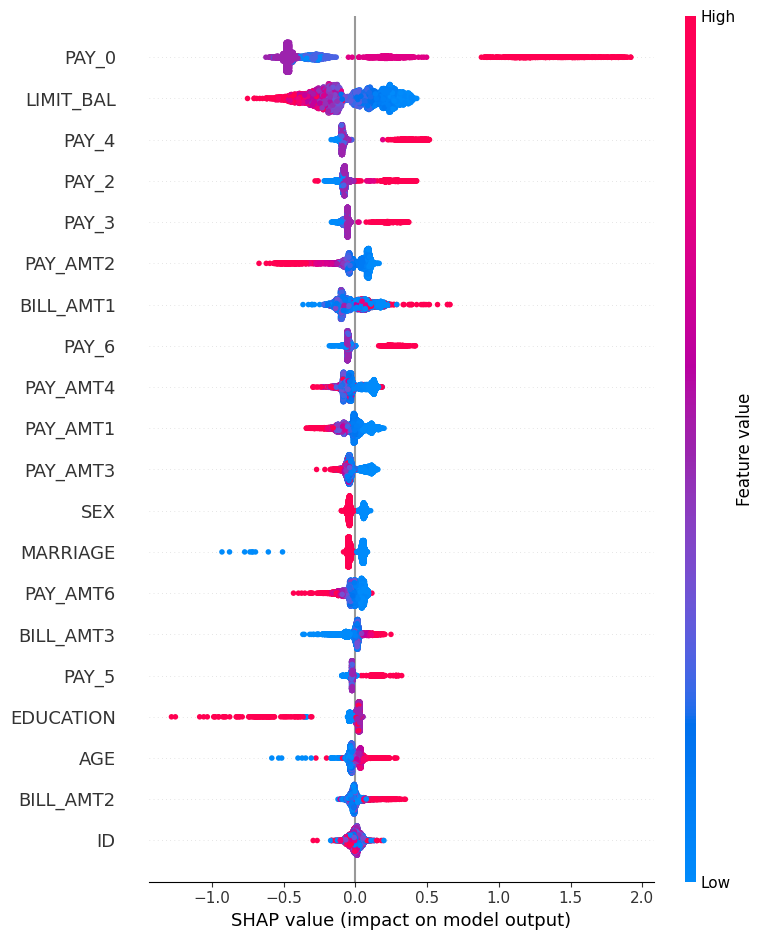

array([[-0.02576019,  0.3118434 ,  0.0546011 , ..., -0.03564276,
        -0.01180704, -0.00210351],
       [-0.0272684 , -0.14499691, -0.04935022, ..., -0.05783893,
        -0.01926361, -0.0279248 ],
       [-0.01154331,  0.21642752, -0.04742704, ..., -0.0504595 ,
        -0.01989267, -0.0295622 ],
       ...,
       [-0.00462914,  0.23969975, -0.04434427, ..., -0.04290827,
        -0.01877699,  0.00279129],
       [-0.00980278,  0.30775363, -0.04107667, ...,  0.0136285 ,
         0.03951337,  0.05637029],
       [-0.16550721, -0.50476692, -0.05641885, ..., -0.07275835,
        -0.06231457, -0.02744889]], shape=(6000, 24))

In [76]:
explain.shap_exp_xgb(X_test, cgb_model_tuned)

In [79]:
evaluate.auc_eval(cgb_model_tuned, X_test, y_test)
evaluate.auc_eval(cgb_model, X_test, y_test)


((array([0.21883333, 0.21886981, 0.2189063 , ..., 1.        , 1.        ,
         1.        ], shape=(6001,)),
  array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.52322925e-03, 7.61614623e-04, 0.00000000e+00], shape=(6001,)),
  array([0.02600115, 0.02628899, 0.02700589, ..., 0.9658295 , 0.9708103 ,
         0.97248925], shape=(6000,))),
 0.5462891362436583)